In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.cleaning import clean_data
from src.features import add_features
from src.preprocessing import create_preprocessor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

from imblearn.pipeline import Pipeline as Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report, roc_auc_score, recall_score

In [3]:
df = pd.read_csv("../data/train.csv")

In [4]:
df = clean_data(df)

In [5]:
df = add_features(df)

In [6]:
X = df.drop(columns = "Churn", axis = 1)
y = df["Churn"]

# Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

# Preprocessing

In [8]:
num_cols = X.select_dtypes(include = np.number).columns.tolist()

In [9]:
cat_cols = X.select_dtypes(include = "object").columns.tolist()

In [10]:
preprocessor = create_preprocessor(num_cols, cat_cols)

In [11]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVC": SVC(probability=True),
    "XGB": XGBClassifier(eval_metric='logloss')
}

In [12]:
results = {}

cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

for name, model in models.items():
    
    if name in ["LogisticRegression", "RandomForest", "DecisionTree"]:
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ])
    else:
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])
    
    
    scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv = cv,
        scoring= scoring,
        n_jobs=-1
    )
    
    results[name] = {
        metric: {
            "mean": scores[f'test_{metric}'].mean(),
            "std": scores[f'test_{metric}'].std()
        }
        for metric in scoring
    }

In [13]:
df_results = pd.DataFrame({
    model: {metric: vals["mean"] for metric, vals in metrics.items()}
    for model, metrics in results.items()
}).T

df_results.sort_values("recall", ascending=False)

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.759145,0.531804,0.780602,0.632441,0.847771
KNN,0.766063,0.563315,0.530435,0.546023,0.783467
XGB,0.782572,0.609600,0.502341,0.550651,0.821457
DecisionTreeClassifier,0.726485,0.485391,0.492977,0.489019,0.652360
SVC,0.803516,0.680737,0.490970,0.570076,0.801537
RandomForestClassifier,0.789849,0.635687,0.486957,0.551214,0.821115


In [14]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [15]:
param_grid = {
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    "RandomForestClassifier": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None],
        "model__class_weight": [None, "balanced"]
    },
    "DecisionTreeClassifier": {
        "model__max_depth": [5, 10, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__class_weight": [None, "balanced"]
    },
    "KNN" : {
        "model__n_neighbors": [3, 5, 7, 11],
        "model__weights": ["uniform", "distance"]
    },
    "SVC" : {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf", "linear"],
        "model__class_weight": [None, "balanced"]
    },
    "XGB" : {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 6, 10],
        "model__learning_rate": [0.01, 0.1, 0.2],
        "model__scale_pos_weight": [1, ratio, ratio*2]
    }
}

In [16]:
tuning_results = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipe, 
        param_grid[name],
        cv=cv,
        scoring="recall",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    # test evaluation
    y_pred = best_model.predict(X_test)
    
    
    test_recall = recall_score(y_test, y_pred)
    test_auc = roc_auc_score(
        y_test,
        best_model.predict_proba(X_test)[:,1]
    )
    
    
    tuning_results[name] = {
        "best_cv_score": grid.best_score_,
        "cv_std": grid.cv_results_["std_test_score"][grid.best_index_],
        "test_recall": test_recall,
        "test_auc": test_auc,
        "best_params": grid.best_params_
    }
    tuning_results[name]["model"] = best_model

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [17]:
df_results = pd.DataFrame(tuning_results).T
df_results.sort_values("test_recall", ascending=False)

,best_cv_score,cv_std,test_recall,test_auc,best_params,model
XGB,0.945819,0.012762,0.946524,0.837079,"{'model__learning_rate': 0.01, 'model__max_dep...","(ColumnTransformer(transformers=[('num',\n ..."
SVC,0.835452,0.019084,0.820856,0.823108,"{'model__C': 0.1, 'model__class_weight': 'bala...","(ColumnTransformer(transformers=[('num',\n ..."
RandomForestClassifier,0.810033,0.024062,0.799465,0.840115,"{'model__class_weight': 'balanced', 'model__ma...","(ColumnTransformer(transformers=[('num',\n ..."
LogisticRegression,0.798662,0.036844,0.783422,0.846142,"{'model__C': 10, 'model__class_weight': 'balan...","(ColumnTransformer(transformers=[('num',\n ..."
DecisionTreeClassifier,0.772575,0.025206,0.759358,0.831165,"{'model__class_weight': 'balanced', 'model__ma...","(ColumnTransformer(transformers=[('num',\n ..."
KNN,0.559197,0.01066,0.574866,0.812629,"{'model__n_neighbors': 11, 'model__weights': '...","(ColumnTransformer(transformers=[('num',\n ..."


In [18]:
df_results = df_results.sort_values("best_cv_score", ascending=False)

In [19]:
best_model_name = df_results.index[0]
print("Best Model:", best_model_name)

Best Model: XGB


In [20]:
best_model = tuning_results[best_model_name]["model"]
best_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [22]:
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.96      0.49      0.65      1035
           1       0.40      0.95      0.56       374

    accuracy                           0.61      1409
   macro avg       0.68      0.72      0.60      1409
weighted avg       0.81      0.61      0.62      1409

ROC-AUC: 0.8370792322198972


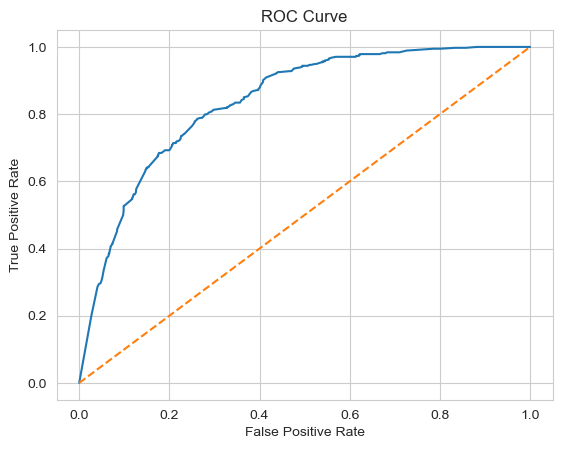

In [23]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [24]:
y_pred_custom = (y_proba >= 0.3).astype(int)

In [28]:
recall_score(y_test, y_pred_custom)

0.9973262032085561

In [26]:
import joblib

joblib.dump(best_model, "../model/churn_model.pkl")

['../model/churn_model.pkl']

In [25]:
preprocessor = best_model.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance["feature"] = feature_importance["feature"].apply(
    lambda x: x.split("__")[-1]
)

feature_importance["feature_group"] = feature_importance["feature"].apply(
    lambda x: x.split("_")[0]
)

grouped_importance = feature_importance.groupby("feature_group")["importance"].sum().reset_index()
grouped_importance = grouped_importance.sort_values(by="importance", ascending=False)

print(grouped_importance.head(10))

      feature_group  importance
1          Contract    0.578699
4   InternetService    0.072692
16      TechSupport    0.069131
8    OnlineSecurity    0.065855
5    MonthlyCharges    0.056361
14  StreamingMovies    0.044555
19           tenure    0.034610
11    PaymentMethod    0.023962
0        AvgCharges    0.018262
7      OnlineBackup    0.017163


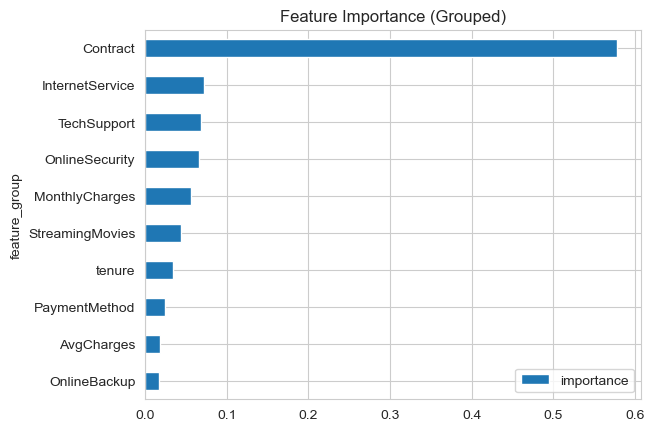

In [26]:
grouped_importance.head(10).plot(
    kind="barh",
    x="feature_group",
    y="importance"
)

plt.gca().invert_yaxis()
plt.title("Feature Importance (Grouped)")
plt.show()